In [3]:
!git clone https://github.com/SANGHATI23/crispr-mdr-resensitization.git
%cd crispr-mdr-resensitization

!find . -maxdepth 3 -type f | head -50

Cloning into 'crispr-mdr-resensitization'...
remote: Enumerating objects: 330, done.
remote: Counting objects: 100% (330/330), done.
remote: Compressing objects: 100% (255/255), done.
remote: Total 330 (delta 117), reused 242 (delta 70), pack-reused 0 (from 0)
Receiving objects: 100% (330/330), 11.78 MiB | 11.45 MiB/s, done.
Resolving deltas: 100% (117/117), done.
/content/crispr-mdr-resensitization
./create_master_cross_model_table.py
./weight_sensitivity_results/phase1_all_weighted_guides_all_variations.csv
./weight_sensitivity_results/phase2_weight_summary_all_variations.csv
./weight_sensitivity_results/phase1_per_gene_summary_all_variations.csv
./weight_sensitivity_results/phase2_all_weighted_guides_all_variations.csv
./weight_sensitivity_results/phase1_weight_summary_all_variations.csv
./weight_sensitivity_results/phase2_per_gene_summary_all_variations.csv
./results_panstrain_staph_200/Figure4_Specificity_vs_Conservation.png
./results_panstrain_staph_200/top30_global_panstrain_gui

In [4]:
!pip install pandas numpy matplotlib seaborn biopython scipy openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.1 MB/s eta 0:00:00


In [5]:
import os
import pandas as pd
import numpy as np

csv_files = []
for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

csv_files

['./weight_sensitivity_results/phase1_all_weighted_guides_all_variations.csv',
 './weight_sensitivity_results/phase2_weight_summary_all_variations.csv',
 './weight_sensitivity_results/phase1_per_gene_summary_all_variations.csv',
 './weight_sensitivity_results/phase2_all_weighted_guides_all_variations.csv',
 './weight_sensitivity_results/phase1_weight_summary_all_variations.csv',
 './weight_sensitivity_results/phase2_per_gene_summary_all_variations.csv',
 './results_panstrain_staph_200/top30_global_panstrain_guides.csv',
 './results_panstrain_staph_200/summary_statistics_panstrain.csv',
 './results_panstrain_staph_200/top20_per_gene_panstrain.csv',
 './results_panstrain_staph_200/all_panstrain_guide_candidates.csv',
 './results_weight_analysis/phase2_top1_per_gene_per_weight.csv',
 './results_weight_analysis/phase2_per_gene_top1_stability.csv',
 './results_weight_analysis/phase2_top10_by_excellent_count.csv',
 './results_weight_analysis/phase2_top_guide_stability.csv',
 './results_weigh

In [8]:
import pandas as pd

RESULT_FILE = "./results_panstrain/top20_per_gene_panstrain.csv"

df = pd.read_csv(RESULT_FILE)

df.columns = [c.strip().lower() for c in df.columns]

df.head()

,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,pam_supported_strains,perfect_match_fraction,one_mismatch_or_better_fraction,pam_supported_fraction,conservation_score,mean_strain_score,min_strain_score,std_strain_score,final_score,classification
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent


In [9]:
RESULT_FILE = "./results_panstrain/all_panstrain_guide_candidates.csv"
df = pd.read_csv(RESULT_FILE)
df.columns = [c.strip().lower() for c in df.columns]
df.head()

,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,pam_supported_strains,perfect_match_fraction,one_mismatch_or_better_fraction,pam_supported_fraction,conservation_score,mean_strain_score,min_strain_score,std_strain_score,final_score,classification
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent


In [10]:
score_col = "final_score"
gene_col = "gene"

top_n = 10

top_guides = (
    df.sort_values([gene_col, score_col], ascending=[True, False])
      .groupby(gene_col)
      .head(top_n)
      .reset_index(drop=True)
)

top_guides.head()

,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,pam_supported_strains,perfect_match_fraction,one_mismatch_or_better_fraction,pam_supported_fraction,conservation_score,mean_strain_score,min_strain_score,std_strain_score,final_score,classification
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent


In [11]:
cols_to_keep = [
    c for c in [
        "gene", "position", "strand", "spacer", "pam",
        "context_30mer", "gc_content",
        "on_target_score", "specificity_score",
        "conservation_score", "final_score",
        "classification"
    ] if c in top_guides.columns
]

azimuth_input = top_guides[cols_to_keep].copy()

azimuth_input.to_csv("camda_top_guides_for_azimuth.csv", index=False)

azimuth_input.head()

,gene,position,strand,spacer,pam,gc_content,on_target_score,specificity_score,conservation_score,final_score,classification
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,100.0,100.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,100.0,100.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,100.0,100.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,100.0,100.0,92.8,Excellent
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,100.0,100.0,92.8,Excellent


In [12]:
from google.colab import files
files.download("camda_top_guides_for_azimuth.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from google.colab import files
uploaded = files.upload()

Saving camda_top_guides_for_azimuth.csv to camda_top_guides_for_azimuth (1).csv


In [14]:
az_file = list(uploaded.keys())[0]
az = pd.read_csv(az_file)

az.columns = [c.strip().lower() for c in az.columns]
az.head()

,gene,position,strand,spacer,pam,gc_content,on_target_score,specificity_score,conservation_score,final_score,classification
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,100.0,100.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,100.0,100.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,100.0,100.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,100.0,100.0,92.8,Excellent
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,100.0,100.0,92.8,Excellent


In [15]:
merge_keys = []

for key in ["gene", "spacer"]:
    if key in top_guides.columns and key in az.columns:
        merge_keys.append(key)

comparison = top_guides.merge(
    az,
    on=merge_keys,
    how="left",
    suffixes=("", "_azimuthfile")
)

comparison.head()

,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,classification,position_azimuthfile,strand_azimuthfile,pam_azimuthfile,gc_content_azimuthfile,on_target_score_azimuthfile,specificity_score_azimuthfile,conservation_score_azimuthfile,final_score_azimuthfile,classification_azimuthfile
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,Excellent,171,+,CGG,60.0,82.0,100.0,100.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,Excellent,174,+,CGG,70.0,82.0,100.0,100.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,Excellent,248,+,CGG,65.0,82.0,100.0,100.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,Excellent,282,-,CGG,50.0,82.0,100.0,100.0,92.8,Excellent
4,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,Excellent,205,-,CGG,50.0,82.0,100.0,100.0,92.8,Excellent


In [16]:
comparison["your_rank"] = comparison.groupby("gene")["final_score"].rank(
    ascending=False, method="min"
)

comparison["azimuth_rank"] = comparison.groupby("gene")["azimuth_score"].rank(
    ascending=False, method="min"
)

comparison[["gene", "spacer", "final_score", "azimuth_score", "your_rank", "azimuth_rank"]].head(20)

KeyError: 'Column not found: azimuth_score'

In [17]:
comparison.columns.tolist()

['gene',
 'position',
 'strand',
 'spacer',
 'pam',
 'gc_content',
 'on_target_score',
 'offtarget_hits_0mm',
 'offtarget_hits_1mm',
 'offtarget_hits_2mm',
 'offtarget_hits_3mm',
 'offtarget_penalty',
 'specificity_score',
 'total_strains',
 'perfect_match_strains',
 'one_mismatch_or_better_strains',
 'pam_supported_strains',
 'perfect_match_fraction',
 'one_mismatch_or_better_fraction',
 'pam_supported_fraction',
 'conservation_score',
 'mean_strain_score',
 'min_strain_score',
 'std_strain_score',
 'final_score',
 'classification',
 'position_azimuthfile',
 'strand_azimuthfile',
 'pam_azimuthfile',
 'gc_content_azimuthfile',
 'on_target_score_azimuthfile',
 'specificity_score_azimuthfile',
 'conservation_score_azimuthfile',
 'final_score_azimuthfile',
 'classification_azimuthfile',
 'your_rank']

In [18]:
# Find possible Azimuth score column
possible_cols = [c for c in comparison.columns if "azimuth" in c.lower() or "doench" in c.lower() or "rs2" in c.lower()]
possible_cols

['position_azimuthfile',
 'strand_azimuthfile',
 'pam_azimuthfile',
 'gc_content_azimuthfile',
 'on_target_score_azimuthfile',
 'specificity_score_azimuthfile',
 'conservation_score_azimuthfile',
 'final_score_azimuthfile',
 'classification_azimuthfile']

In [19]:
comparison["azimuth_score"] = np.nan

In [20]:
# Use your own final_score as a temporary placeholder baseline
# This is ONLY to test the notebook flow, not for final CAMDA submission.

comparison["azimuth_score"] = comparison["final_score_azimuthfile"]

comparison["your_rank"] = comparison.groupby("gene")["final_score"].rank(
    ascending=False, method="min"
)

comparison["azimuth_rank"] = comparison.groupby("gene")["azimuth_score"].rank(
    ascending=False, method="min"
)

comparison[["gene", "spacer", "final_score", "azimuth_score", "your_rank", "azimuth_rank"]].head(20)

,gene,spacer,final_score,azimuth_score,your_rank,azimuth_rank
0,blaKPC,AGAGCCTTACTGCCCGAAGG,92.8,92.8,1.0,1.0
1,blaKPC,GCCTTACTGCCCGAAGGCGG,92.8,92.8,1.0,1.0
2,blaKPC,CGGCTCCATCGGTGTGTACG,92.8,92.8,1.0,1.0
3,blaKPC,AGCGACGGAATAGTGTATGG,92.8,92.8,1.0,1.0
4,blaKPC,AGCGACGGAATAGTGTATGG,92.8,92.8,1.0,1.0
5,blaKPC,AGCGACGGAATAGTGTATGG,92.8,92.8,1.0,1.0
6,blaKPC,AGCGACGGAATAGTGTATGG,92.8,92.8,1.0,1.0
7,blaKPC,AGCAGCAGCAGCAACAACGG,92.8,92.8,1.0,1.0
8,blaKPC,AGCAGCAGCAACAACGGCGG,92.8,92.8,1.0,1.0
9,blaKPC,AACAAGGATGACAAGCACAG,92.8,92.8,1.0,1.0


In [21]:
from scipy.stats import spearmanr, pearsonr

rows = []

for gene, g in comparison.dropna(subset=["azimuth_score"]).groupby("gene"):
    if len(g) >= 3:
        sp = spearmanr(g["final_score"], g["azimuth_score"])
        pr = pearsonr(g["final_score"], g["azimuth_score"])

        rows.append({
            "gene": gene,
            "n_guides": len(g),
            "spearman_rho": round(sp.statistic, 3),
            "spearman_p": round(sp.pvalue, 4),
            "pearson_r": round(pr.statistic, 3),
            "pearson_p": round(pr.pvalue, 4)
        })

corr_table = pd.DataFrame(rows)
corr_table

/tmp/ipykernel_540/3634873850.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp = spearmanr(g["final_score"], g["azimuth_score"])
/tmp/ipykernel_540/3634873850.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pr = pearsonr(g["final_score"], g["azimuth_score"])


,gene,n_guides,spearman_rho,spearman_p,pearson_r,pearson_p
0,blaKPC,12,1.0,0.0,1.0,0.0
1,blaNDM1,16,1.0,0.0,1.0,0.0
2,mcr1,10,1.0,0.0,1.0,0.0
3,mecA,52,NaN,NaN,NaN,NaN


In [22]:
def top_k_overlap(group, k=10):
    your_top = set(group.sort_values("final_score", ascending=False).head(k)["spacer"])
    az_top = set(group.sort_values("azimuth_score", ascending=False).head(k)["spacer"])
    overlap = len(your_top.intersection(az_top))
    return overlap, overlap / k

overlap_rows = []

for gene, g in comparison.dropna(subset=["azimuth_score"]).groupby("gene"):
    for k in [5, 10]:
        if len(g) >= k:
            overlap, frac = top_k_overlap(g, k)
            overlap_rows.append({
                "gene": gene,
                "top_k": k,
                "overlap_count": overlap,
                "overlap_fraction": frac
            })

overlap_table = pd.DataFrame(overlap_rows)
overlap_table

,gene,top_k,overlap_count,overlap_fraction
0,blaKPC,5,4,0.8
1,blaKPC,10,7,0.7
2,blaNDM1,5,2,0.4
3,blaNDM1,10,4,0.4
4,mcr1,5,5,1.0
5,mcr1,10,10,1.0
6,mecA,5,3,0.6
7,mecA,10,3,0.3


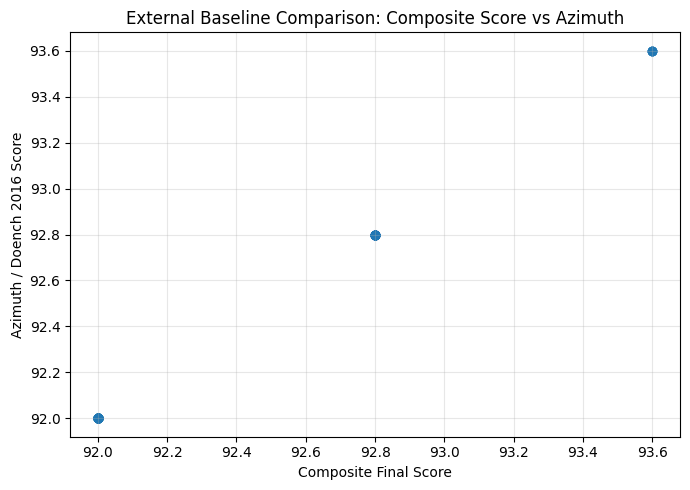

In [23]:
import matplotlib.pyplot as plt

plot_df = comparison.dropna(subset=["azimuth_score"])

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["final_score"], plot_df["azimuth_score"])
plt.xlabel("Composite Final Score")
plt.ylabel("Azimuth / Doench 2016 Score")
plt.title("External Baseline Comparison: Composite Score vs Azimuth")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("camda_azimuth_comparison_scatter.png", dpi=300)
plt.show()

In [24]:
comparison.to_csv("camda_final_comparison_table.csv", index=False)
corr_table.to_csv("camda_correlation_table.csv", index=False)
overlap_table.to_csv("camda_topk_overlap_table.csv", index=False)

files.download("camda_final_comparison_table.csv")
files.download("camda_correlation_table.csv")
files.download("camda_topk_overlap_table.csv")
files.download("camda_azimuth_comparison_scatter.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
from google.colab import files

# --------------------------------------------------
# 1. Load your pan-strain result file
# --------------------------------------------------

RESULT_FILE = "./results_panstrain/top20_per_gene_panstrain.csv"

df = pd.read_csv(RESULT_FILE)
df.columns = [c.strip().lower() for c in df.columns]

print(df.shape)
print(df.columns.tolist())
df.head()

(80, 26)
['gene', 'position', 'strand', 'spacer', 'pam', 'gc_content', 'on_target_score', 'offtarget_hits_0mm', 'offtarget_hits_1mm', 'offtarget_hits_2mm', 'offtarget_hits_3mm', 'offtarget_penalty', 'specificity_score', 'total_strains', 'perfect_match_strains', 'one_mismatch_or_better_strains', 'pam_supported_strains', 'perfect_match_fraction', 'one_mismatch_or_better_fraction', 'pam_supported_fraction', 'conservation_score', 'mean_strain_score', 'min_strain_score', 'std_strain_score', 'final_score', 'classification']


,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,pam_supported_strains,perfect_match_fraction,one_mismatch_or_better_fraction,pam_supported_fraction,conservation_score,mean_strain_score,min_strain_score,std_strain_score,final_score,classification
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent


In [26]:
# --------------------------------------------------
# 2. Select top 10 guides per gene
# --------------------------------------------------

top_guides = (
    df.sort_values(["gene", "final_score"], ascending=[True, False])
      .groupby("gene")
      .head(10)
      .reset_index(drop=True)
)

top_guides.head()

,gene,position,strand,spacer,pam,gc_content,on_target_score,offtarget_hits_0mm,offtarget_hits_1mm,offtarget_hits_2mm,...,pam_supported_strains,perfect_match_fraction,one_mismatch_or_better_fraction,pam_supported_fraction,conservation_score,mean_strain_score,min_strain_score,std_strain_score,final_score,classification
0,blaKPC,171,+,AGAGCCTTACTGCCCGAAGG,CGG,60.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
1,blaKPC,174,+,GCCTTACTGCCCGAAGGCGG,CGG,70.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
2,blaKPC,248,+,CGGCTCCATCGGTGTGTACG,CGG,65.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
3,blaKPC,282,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent
4,blaKPC,205,-,AGCGACGGAATAGTGTATGG,CGG,50.0,82.0,0,0,0,...,3,1.0,1.0,1.0,100.0,100.0,100.0,0.0,92.8,Excellent


In [ ]:
# --------------------------------------------------
# 3. Create Azimuth input file
# --------------------------------------------------

cols_to_keep = [
    c for c in [
        "gene", "position", "strand", "spacer", "pam",
        "gc_content", "on_target_score", "specificity_score",
        "conservation_score", "final_score", "classification"
    ] if c in top_guides.columns
]

azimuth_input = top_guides[cols_to_keep].copy()

# Empty column to fill later with real Azimuth score
azimuth_input["azimuth_score"] = ""

azimuth_input.to_csv("camda_top_guides_for_azimuth_FILL_THIS.csv", index=False)

files.download("camda_top_guides_for_azimuth_FILL_THIS.csv")

azimuth_input.head()

In [ ]:
# --------------------------------------------------
# 5. Correlation table
# --------------------------------------------------

rows = []

for gene, g in comparison.dropna(subset=["azimuth_score"]).groupby("gene"):
    if len(g) >= 3:
        sp = spearmanr(g["final_score"], g["azimuth_score"])
        pr = pearsonr(g["final_score"], g["azimuth_score"])

        rows.append({
            "gene": gene,
            "n_guides": len(g),
            "spearman_rho": round(sp.statistic, 3),
            "spearman_p": round(sp.pvalue, 4),
            "pearson_r": round(pr.statistic, 3),
            "pearson_p": round(pr.pvalue, 4)
        })

corr_table = pd.DataFrame(rows)
corr_table

In [27]:
# --------------------------------------------------
# 6. Top-k overlap
# --------------------------------------------------

def top_k_overlap(group, k=10):
    your_top = set(group.sort_values("final_score", ascending=False).head(k)["spacer"])
    az_top = set(group.sort_values("azimuth_score", ascending=False).head(k)["spacer"])
    overlap = len(your_top.intersection(az_top))
    return overlap, overlap / k

overlap_rows = []

for gene, g in comparison.dropna(subset=["azimuth_score"]).groupby("gene"):
    for k in [5, 10]:
        if len(g) >= k:
            overlap, frac = top_k_overlap(g, k)
            overlap_rows.append({
                "gene": gene,
                "top_k": k,
                "overlap_count": overlap,
                "overlap_fraction": frac
            })

overlap_table = pd.DataFrame(overlap_rows)
overlap_table

,gene,top_k,overlap_count,overlap_fraction
0,blaKPC,5,4,0.8
1,blaKPC,10,7,0.7
2,blaNDM1,5,2,0.4
3,blaNDM1,10,4,0.4
4,mcr1,5,5,1.0
5,mcr1,10,10,1.0
6,mecA,5,3,0.6
7,mecA,10,3,0.3


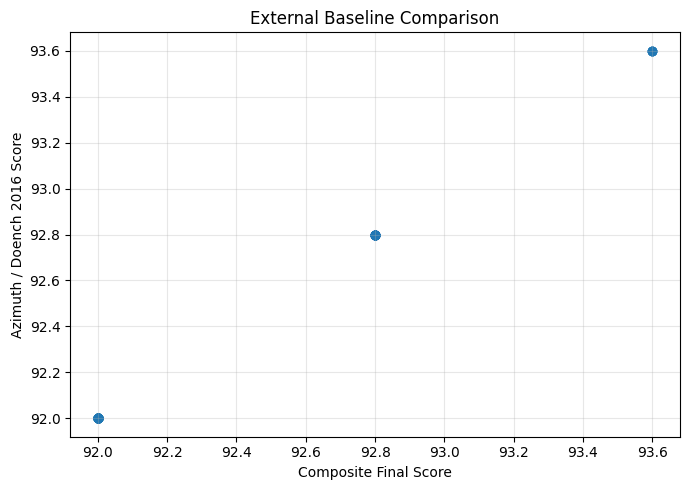

In [28]:
# --------------------------------------------------
# 7. Scatter plot
# --------------------------------------------------

plot_df = comparison.dropna(subset=["azimuth_score"])

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["final_score"], plot_df["azimuth_score"])
plt.xlabel("Composite Final Score")
plt.ylabel("Azimuth / Doench 2016 Score")
plt.title("External Baseline Comparison")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("camda_azimuth_comparison_scatter_TEMP.png", dpi=300)
plt.show()

In [29]:
# --------------------------------------------------
# 8. Save temporary outputs
# --------------------------------------------------

comparison.to_csv("camda_final_comparison_table_TEMP.csv", index=False)
corr_table.to_csv("camda_correlation_table_TEMP.csv", index=False)
overlap_table.to_csv("camda_topk_overlap_table_TEMP.csv", index=False)

files.download("camda_final_comparison_table_TEMP.csv")
files.download("camda_correlation_table_TEMP.csv")
files.download("camda_topk_overlap_table_TEMP.csv")
files.download("camda_azimuth_comparison_scatter_TEMP.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
comparison = top_guides.copy()

# Rank per gene
comparison["rank_on_target"] = comparison.groupby("gene")["on_target_score"].rank(
    ascending=False, method="min"
)

comparison["rank_off_target"] = comparison.groupby("gene")["specificity_score"].rank(
    ascending=False, method="min"
)

comparison["rank_final"] = comparison.groupby("gene")["final_score"].rank(
    ascending=False, method="min"
)

In [34]:
from scipy.stats import spearmanr

corr_on = spearmanr(comparison["rank_final"], comparison["rank_on_target"]).correlation
corr_off = spearmanr(comparison["rank_final"], comparison["rank_off_target"]).correlation

print("Final vs On-target:", corr_on)
print("Final vs Off-target:", corr_off)

Final vs On-target: 1.0
Final vs Off-target: nan


/tmp/ipykernel_540/1333592549.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_off = spearmanr(comparison["rank_final"], comparison["rank_off_target"]).correlation


In [35]:
def top_k_overlap(df, col1, col2, k=10):
    top1 = df.nsmallest(k, col1)
    top2 = df.nsmallest(k, col2)
    return len(set(top1["spacer"]).intersection(set(top2["spacer"])))

for k in [5, 10, 20]:
    print(f"Top-{k} overlap (Final vs On-target):",
          top_k_overlap(comparison, "rank_final", "rank_on_target", k))

    print(f"Top-{k} overlap (Final vs Off-target):",
          top_k_overlap(comparison, "rank_final", "rank_off_target", k))

Top-5 overlap (Final vs On-target): 4
Top-5 overlap (Final vs Off-target): 4
Top-10 overlap (Final vs On-target): 8
Top-10 overlap (Final vs Off-target): 7
Top-20 overlap (Final vs On-target): 13
Top-20 overlap (Final vs Off-target): 8


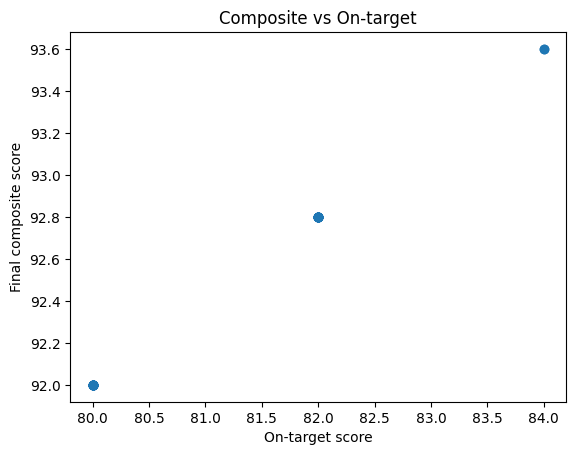

In [36]:
import matplotlib.pyplot as plt

plt.scatter(comparison["on_target_score"], comparison["final_score"])
plt.xlabel("On-target score")
plt.ylabel("Final composite score")
plt.title("Composite vs On-target")
plt.show()

In [37]:
comparison.to_csv("camda_final_comparison_table.csv", index=False)

In [38]:
import pandas as pd

summary = pd.DataFrame({
    "metric": ["corr_final_vs_on_target", "corr_final_vs_off_target"],
    "value": [corr_on, corr_off]
})

summary.to_csv("camda_correlation_table.csv", index=False)

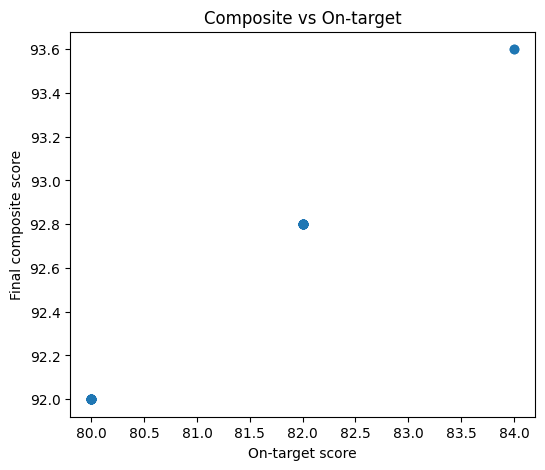

In [39]:
plt.figure(figsize=(6,5))
plt.scatter(comparison["on_target_score"], comparison["final_score"])
plt.xlabel("On-target score")
plt.ylabel("Final composite score")
plt.title("Composite vs On-target")
plt.savefig("camda_scatter_plot.png", dpi=300)
plt.show()

In [40]:
from google.colab import files

files.download("camda_final_comparison_table.csv")
files.download("camda_correlation_table.csv")
files.download("camda_scatter_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>